# `DreamerV3` agent: Beyond memorization of dynamics
In the last notebook, we analyzed the performance of a simple "tabular" agent in MiniGrid, which only sees a simplified observation (coordinate + heading direction) rather than the standard MiniGrid observation (a partial view of the environment). The reason for the simplified setup was to analyze the effect of different intrinsic motivations in a setting where everything is still well-computable and interpretable - we can understand why an agent that has visited a certain state once, will have a worse understanding of the dynamics in this state than in another state that the agent has seen 100 times: the fact that each state is identified by its coordinate and there is no representation learning on top of these observations means that the agent cannot generalize to infer the transition probabilities of a new state from known states. This allows us to compute information gain and empowerment more or less exactly, but also means all of it is limited by the simplified lens (observation) through which we force the agent to perceive the world: Even if the agent has "seen" 10 floor tiles and 10 ice tiles and learned that it slips on the ice tiles and not on the floor tiles, it will not be able to infer that a floor tile at a new coordinate is in fact a floor tile and thus safe to step on without trying it out and learning the dynamics on this tile from scratch. Depending on how you set up the prior, this can lead to a pessimistic agent that does not want to explore new tiles because they are completely unknown. 

But what if the agent could transfer learned knowledge to future situations? Shouldn't it then be able to generalize the concept of ice vs. floor tiles, and understand that a floor tile is safe to step on, regardless of whether this exact floor tile has been visited before? And what if it can learn on its own what is important? What will it be surprised by? And what will it consider empowering?

This is what this notebook aims to shed light on: We will analyze the performance of a much more sophisticated, deep (model-based) RL agent, [DreamerV3](https://github.com/danijar/dreamerv3), and try to see whether similar trends hold as in the "tabular" setting. Again, we will use the custom environment `MixedEnv`, a modified MiniGrid environment where random exploration alone is highly likely to result in dying and being reset to the starting state, and thus not enough to explore the entire map.

In particular, these are some questions that we'd like to answer:
* Is our implementation of high-dimensional / latent information gain still able to distinguish epistemic (reducible) and aleatoric (irreducible) uncertainty?
* Does our implementation of high-dimensional / latent empowerment yield a similar ranking of higher-empowerment (floor tile in the middle of the room) vs. lower-empowerment (corners, ice patch) states as in the tabular setting?
* Is a combination of empowerment and information gain more beneficial than either alone?
* Does an agent trained with intrinsic reward learn to focus its attention on different aspects than one trained with no reward / extrinsic reward? I.e. do the learned latent representations differ? 

---

> Note: The data below was obtained by running `sbatch $WORK/empowerment-and-human-behavior/world_model/dreamerv3/hpc.sh` multiple times, each time with modified contents. To run a single agent with e.g. the factorized state surprise as reward and no extrinsic reward, you need to provide a specific config in `$WORK/empowerment-and-human-behavior/world_model/dreamerv3/configs.yaml` and set it in the run command in `hpc.sh`, e.g. like so:
>
> `python -m dreamerv3 --configs minigrid-pretrain-mixedenv --logdir "/mnt/lustre/work/wu/wkn758/dreamer_pretrain/mixedenv/MixedEnv/latentsnoveltyperstatefactorized" `
> 
> (assuming that the minigrid-pretrain-mixedenv config in `configs.yaml` has been set to 
> * `latents_intrinsic: latentsnoveltyperstatefactorized` 
> * `ignore_extr_reward: True`
> 
> )

## 1. Analysis of a single run

In [ ]:
# Enable imports from src directory
import sys
sys.path.append('../src')

# Enable autoreload so that changes in source files are automatically reloaded
# when running any code in this notebook
%load_ext autoreload
%autoreload 2

In [2]:
import tensorflow as tf
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

2025-07-09 15:05:17.697646: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-09 15:05:18.548280: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# TODO: Dirty hack for now because is_terminal seems to include truncation, which we do not want
from environment import MixedEnv

temp_env = MixedEnv()
temp_env.reset()

# get all lava cells 
DEATH_CELLS = []

for i in range(temp_env.grid.width):
    for j in range(temp_env.grid.height):
        cell = temp_env.grid.get(i, j)
        if cell is not None and cell.type == "lava":
            DEATH_CELLS.append((i, j))
print(f"Found {len(DEATH_CELLS)} lava cells")
print(f"Death cells: {DEATH_CELLS}")

Found 8 lava cells
Death cells: [(1, 8), (2, 10), (3, 7), (4, 1), (5, 2), (5, 4), (6, 6), (9, 7)]


In [4]:
DEATH_CELLS = []

In [17]:
from IPython.display import display, HTML
import glob
from matplotlib import animation
import numpy as np
import os
import matplotlib.pyplot as plt
from ipywidgets import widgets, interactive_output, interact, IntSlider, FloatSlider, Button, HBox, VBox, Layout
from scipy.special import softmax

# Configuration
AGENT_NAME = "infogain_empowerment_mul_basedonpreviousstate"
BASE_PATH = "/mnt/lustre/work/wu/wkn758/dreamer_pretrain/mixedenv/MixedEnv"  
# BASE_PATH = "/mnt/lustre/work/wu/wkn758/dreamer_pretrain/mixedenvwithgoalinstartingcorner/MixedEnvWithGoalInStartingCorner"  
REPLAY_PATH = f"{BASE_PATH}/{AGENT_NAME}/replay"

if "crafter" in BASE_PATH:
    import crafter
    ACTION_NAMES = crafter.constants.actions
    print(f"Using Crafter action names: {ACTION_NAMES}")
else:
    # Assuming MiniGrid
    # Get action names from the environment directly (minigrid package)
    from minigrid.core.actions import Actions
    ACTION_NAMES = [action.name for action in Actions]
    print(f"Using MiniGrid action names: {ACTION_NAMES}")

# Define the color map for intrinsic reward components
color_map = {
    'Novelty': '#0063be',
    'Information Gain': '#fed900',
    'Empowerment': '#007836',
    'Mean': '#ff6f20',
    'Product': '#580f8b',
    'None': '#000000', 
}

# Function to load replay files chronologically
def load_replay_files(replay_path):
    """Load replay files sorted by creation time (to approximate training progression)"""
    files = glob.glob(os.path.join(replay_path, "*.npz"))
    # Sort files by creation time to track progression through training
    files = sorted(files, key=os.path.getmtime)
    return files

# Function to load data from a specific replay file
def load_replay_data(filepath):
    """Load data from a replay file."""
    return np.load(filepath, allow_pickle=True)

# Function to plot rewards over entire training data
def plot_training_rewards(replay_files, step_interval=1, figsize=(15, 8)):
    """
    Plot rewards over entire training to identify interesting regions.
    Shows rewards across files with markers for episode boundaries.
    
    Args:
        replay_files: List of replay file paths
        step_interval: Plot every N steps to reduce plot density
        figsize: Figure size
    
    Returns:
        Dictionary mapping global step indices to (file_idx, local_step_idx)
        List of file boundaries
        List of episode boundary steps
    """
    plt.figure(figsize=figsize)
    
    # Initialize storage for reward data
    all_total_rewards = []
    all_extrinsic_rewards = []
    all_intrinsic_rewards = []
    component_rewards = {}
    global_steps = []
    
    # Track mappings from global steps to file and local step
    global_to_local_map = {}
    file_boundaries = [0]  # Global step indices where files begin
    episode_boundaries = []  # Global steps where episodes begin/end
    global_step = 0
    
    # Process each file
    print("Processing data and collecting episode boundaries...")
    for file_idx, filepath in enumerate(replay_files):
        print(f"Processing file {file_idx+1}/{len(replay_files)}: {os.path.basename(filepath)}")
        data = load_replay_data(filepath)
        
        # Extract rewards, subsampling to reduce plot density
        steps_in_file = len(data["reward"])
        indices = np.arange(0, steps_in_file, step_interval)
        
        # Map every step (not just sampled ones) to global index for accurate retrieval later
        for local_idx in range(steps_in_file):
            global_to_local_map[global_step + local_idx] = (file_idx, local_idx)
            
            # Track episode boundaries
            if "is_first" in data and data["is_first"][local_idx]:
                episode_boundaries.append(global_step + local_idx)
        
        # For plotting, only use subsampled indices
        for local_idx in indices:
            global_steps.append(global_step + local_idx)
            
            # Use the already scaled rewards
            all_total_rewards.append(data["reward"][local_idx])
            all_extrinsic_rewards.append(data["extrinsic_reward"][local_idx])
            all_intrinsic_rewards.append(data["intrinsic_reward"][local_idx])
            
            # Collect only non-raw component rewards
            for key in data.keys():
                if key.startswith("intrinsic_reward_") and not key.endswith("_raw") and len(data[key].shape) == 1:
                    if key not in component_rewards:
                        component_rewards[key] = []
                    component_rewards[key].append(data[key][local_idx])
        
        # Track file boundary
        global_step += steps_in_file
        file_boundaries.append(global_step)
    
    print(f"Found {len(episode_boundaries)} episode starts")
    
    # Plot rewards
    # plt.plot(global_steps, all_total_rewards, label="Total", color='red')
    plt.plot(global_steps, all_extrinsic_rewards, label="Extrinsic", color='blue')
    # Use the right name and color depending on whether mean or product was used
    if "mean" in AGENT_NAME.lower():
        plt.plot(global_steps, all_intrinsic_rewards, label="Total Intrinsic Reward (Mean)", color=color_map['Mean'])
    elif "mul" in AGENT_NAME.lower():
        plt.plot(global_steps, all_intrinsic_rewards, label="Total Intrinsic Reward (Product)", color=color_map['Product'])
    
    # Plot component rewards with custom colors
    for key, values in component_rewards.items():
        label = key.replace("intrinsic_reward_", "")
        # Map label to standardized name for color mapping
        color_key = None
        if "novelty" in label.lower():
            color_key = "Novelty"
        elif "infogain" in label.lower() or "information" in label.lower():
            color_key = "Information Gain"
        elif "empowerment" in label.lower():
            color_key = "Empowerment"
        
        # Use custom color if available, otherwise use default colors
        if color_key and color_key in color_map:
            plt.plot(global_steps, values, label=color_key, 
                    color=color_map[color_key], linestyle='--', alpha=0.7)
        else:
            plt.plot(global_steps, values, label=label, 
                    linestyle='--', alpha=0.7)
    
    # Add vertical lines for episode boundaries
    for boundary in episode_boundaries:
        plt.axvline(x=boundary, color='gray', linestyle='--', alpha=0.3)
    
    plt.title(f"Rewards Over Training - {AGENT_NAME}")
    plt.xlabel("Global Step")
    plt.ylabel("Reward")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Add a horizontal line at y=0
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # Add an interactive selector to show step ranges
    plt.tight_layout()
    plt.show()
    
    return global_to_local_map, file_boundaries, episode_boundaries

# Function to extract data for a specific step range
def extract_step_range(replay_files, global_to_local_map, start_step, end_step):
    """
    Extract data for a specific global step range.
    
    Args:
        replay_files: List of replay file paths
        global_to_local_map: Mapping from global steps to (file_idx, local_step)
        start_step: Global starting step
        end_step: Global ending step
    
    Returns:
        Dictionary with data for the requested range
    """
    # Find the actual available steps
    available_steps = sorted(global_to_local_map.keys())
    
    # Ensure steps are within available range
    if start_step < available_steps[0]:
        print(f"Warning: Start step {start_step} is before first available step ({available_steps[0]})")
        start_step = available_steps[0]
    
    if end_step > available_steps[-1]:
        print(f"Warning: End step {end_step} is after last available step ({available_steps[-1]})")
        end_step = available_steps[-1]
    
    # Ensure end > start
    if end_step <= start_step:
        print(f"Warning: End step must be greater than start step. Using start_step+100.")
        end_step = min(start_step + 100, available_steps[-1])
    
    print(f"Extracting steps {start_step} to {end_step}")
    
    # Get file and local indices directly (no approximate matching)
    start_file_idx, start_local_idx = global_to_local_map[start_step]
    end_file_idx, end_local_idx = global_to_local_map[end_step]
    
    print(f"Start: File {start_file_idx}, Local step {start_local_idx}")
    print(f"End: File {end_file_idx}, Local step {end_local_idx}")
    
    # Handle case where range spans multiple files
    if start_file_idx == end_file_idx:
        # Range is within a single file
        data = load_replay_data(replay_files[start_file_idx])
        extract = {}
        for key, value in data.items():
            if isinstance(value, np.ndarray) and len(value) > start_local_idx:
                end_idx = min(end_local_idx + 1, len(value))
                extract[key] = value[start_local_idx:end_idx]
            else:
                extract[key] = value
        return extract
    else:
        # Range spans multiple files - need to concatenate
        print(f"Selected range spans {end_file_idx - start_file_idx + 1} files")
        combined_data = {}
        
        # Process first file
        first_file_data = load_replay_data(replay_files[start_file_idx])
        for key, value in first_file_data.items():
            if isinstance(value, np.ndarray) and len(value) > start_local_idx:
                combined_data[key] = [value[start_local_idx:]]
            else:
                combined_data[key] = value
        
        # Process middle files (if any)
        for file_idx in range(start_file_idx + 1, end_file_idx):
            file_data = load_replay_data(replay_files[file_idx])
            for key in combined_data:
                if isinstance(combined_data[key], list):
                    combined_data[key].append(file_data[key])
        
        # Process last file
        last_file_data = load_replay_data(replay_files[end_file_idx])
        for key in combined_data:
            if isinstance(combined_data[key], list):
                end_idx = min(end_local_idx + 1, len(last_file_data[key]))
                combined_data[key].append(last_file_data[key][:end_idx])
                # Concatenate arrays
                combined_data[key] = np.concatenate(combined_data[key])
        
        return combined_data

def visualize_step_range(data, title="Selected Training Region", use_animation=True, max_frames=150):
    """
    Visualize a specific range of steps with reward plots and latent visualizations.
    
    Args:
        data: Dictionary with data for the step range
        title: Title for the visualization
        use_animation: Whether to use animation or interactive slider
        max_frames: Maximum frames to show (for animation)
    
    Returns:
        Animation or interactive widget
    """    
    # Calculate total steps
    step_count = len(data["image"])
    print(f"Visualizing {step_count} steps")
    
    # Check if we need to subsample
    if step_count > max_frames and use_animation:
        print(f"Step range ({step_count}) exceeds maximum frames ({max_frames}). "
              f"Subsampling for animation.")
        subsample_rate = step_count // max_frames + 1
        indices = np.arange(0, step_count, subsample_rate)
        subsampled_data = {}
        for key, value in data.items():
            if isinstance(value, np.ndarray) and len(value) == step_count:
                subsampled_data[key] = value[indices]
            else:
                subsampled_data[key] = value
        data = subsampled_data
        step_count = len(data["image"])
    

    # Determine which reward components are available - skip raw rewards
    reward_components = []
    for key in data.keys():
        if key.startswith("intrinsic_reward_") and not key.endswith("_raw") and len(data[key].shape) == 1:
            reward_components.append(key)
    
    # Find episode boundaries within this range
    episode_starts = []
    if "is_first" in data:
        episode_starts = np.where(data["is_first"] == 1)[0]
    
    # Check if latent data is available
    has_latents = all(key in data for key in ["latent_stoch", "latent_logit", "prev_latent_stoch", "prev_latent_logit"])
    
    # Find indices with highest and lowest intrinsic rewards
    intrinsic_rewards = data["intrinsic_reward"].flatten()
    highest_indices = np.argsort(intrinsic_rewards)[-30:][::-1]  # Top 20 indices (highest to lowest)
    lowest_indices = np.argsort(intrinsic_rewards)[:30]  # Bottom 20 indices (lowest to highest)
    
    print(f"Highest intrinsic reward indices: {highest_indices}")
    print(f"Highest intrinsic reward values: {intrinsic_rewards[highest_indices]}")
    print(f"Lowest intrinsic reward indices: {lowest_indices}")
    print(f"Lowest intrinsic reward values: {intrinsic_rewards[lowest_indices]}")
    
    if use_animation:
        raise NotImplementedError("Animation mode is not implemented at the moment.")
    else:
        # Create interactive widget with buttons for high/low points
        frame_slider = IntSlider(min=0, max=step_count-1, step=1, value=0, 
                               description='Step:', continuous_update=False,
                               layout=Layout(width='80%'))
        
        # Create buttons for navigation
        btn_prev_high = Button(description='⬅ Prev High', layout=Layout(width='120px'))
        btn_next_high = Button(description='Next High ➡', layout=Layout(width='120px'))
        btn_prev_low = Button(description='⬅ Prev Low', layout=Layout(width='120px'))
        btn_next_low = Button(description='Next Low ➡', layout=Layout(width='120px'))
        
        # Keep track of current position in high/low lists
        high_idx = IntSlider(min=0, max=len(highest_indices)-1, step=1, value=0)
        low_idx = IntSlider(min=0, max=len(lowest_indices)-1, step=1, value=0)
        
        # Define button click handlers
        def on_prev_high_clicked(b):
            high_idx.value = max(0, high_idx.value - 1)
            frame_slider.value = highest_indices[high_idx.value]
            
        def on_next_high_clicked(b):
            high_idx.value = min(len(highest_indices)-1, high_idx.value + 1)
            frame_slider.value = highest_indices[high_idx.value]
            
        def on_prev_low_clicked(b):
            low_idx.value = max(0, low_idx.value - 1)
            frame_slider.value = lowest_indices[low_idx.value]
            
        def on_next_low_clicked(b):
            low_idx.value = min(len(lowest_indices)-1, low_idx.value + 1)
            frame_slider.value = lowest_indices[low_idx.value]
        
        # Connect button click handlers
        btn_prev_high.on_click(on_prev_high_clicked)
        btn_next_high.on_click(on_next_high_clicked)
        btn_prev_low.on_click(on_prev_low_clicked)
        btn_next_low.on_click(on_next_low_clicked)
        
        # Function to plot frame when slider changes
        def plot_frame(frame):
            if has_latents:
                # Create a figure with a more appropriate grid layout
                fig = plt.figure(figsize=(20, 15))
                
                # Create a custom grid with different column widths
                # Make the middle column (rewards) wider than the others
                gs = fig.add_gridspec(2, 3, height_ratios=[1, 0.5], width_ratios=[0.6, 2.5, 0.6])
                
                # Top row - original visualizations
                img_ax = fig.add_subplot(gs[0, 0])
                rewards_ax = fig.add_subplot(gs[0, 1])  # This will be much wider now
                table_ax = fig.add_subplot(gs[0, 2])
                
                # Bottom row - latent visualizations
                latent_row_gs = gs[1, :].subgridspec(1, 4)
                prev_stoch_ax = fig.add_subplot(latent_row_gs[0])
                curr_stoch_ax = fig.add_subplot(latent_row_gs[1])
                prev_logit_ax = fig.add_subplot(latent_row_gs[2])
                curr_logit_ax = fig.add_subplot(latent_row_gs[3])
            else:
                # Use original layout
                fig, axes = plt.subplots(1, 3, figsize=(20, 6))
                img_ax, rewards_ax, table_ax = axes
                prev_stoch_ax = curr_stoch_ax = prev_logit_ax = curr_logit_ax = None
            
            # Add indicator if this is a high/low point
            special_indicator = ""
            if frame in highest_indices:
                idx = np.where(highest_indices == frame)[0][0]
                special_indicator = f" (High #{idx+1} - Rank {idx+1}/{len(highest_indices)})"
            elif frame in lowest_indices:
                idx = np.where(lowest_indices == frame)[0][0]
                special_indicator = f" (Low #{idx+1} - Rank {len(highest_indices)-idx}/{len(lowest_indices)})"
                
            plt.suptitle(f"{title} (Step {frame}/{step_count-1}){special_indicator}", fontsize=16)
            
            # Plot image
            img_ax.imshow(data["image"][frame])
            
            # Add episode indicator to title if applicable
            if frame in episode_starts:
                img_ax.set_title(f"Observation (Step {frame}/{step_count-1}) - Episode Start")
            else:
                img_ax.set_title(f"Observation (Step {frame}/{step_count-1})")
            
            img_ax.axis('off')
            
            # Plot rewards
            rewards_ax.set_title("Rewards")
            rewards_ax.set_xlabel("Step")
            rewards_ax.set_ylabel("Reward")
            
            # Plot reward lines
            steps = list(range(min(frame+1, step_count)))
            
            # plot total only if more than one component 
            # if len(reward_components) > 1:
            #     rewards_ax.plot(steps, data["reward"][:frame+1], label="Total", color='red')
            
            rewards_ax.plot(steps, data["extrinsic_reward"][:frame+1], label="Extrinsic", color='blue')
            # Use the right name and color depending on whether mean or product was used
            if "mean" in AGENT_NAME.lower():
                rewards_ax.plot(steps, data["intrinsic_reward"][:frame+1], 
                              label="Total Intrinsic Reward (Mean)", color=color_map['Mean'])
            elif "mul" in AGENT_NAME.lower():
                rewards_ax.plot(steps, data["intrinsic_reward"][:frame+1], 
                              label="Total Intrinsic Reward (Product)", color=color_map['Product'])
            
            # Add component reward lines with custom colors
            for comp in reward_components:
                label = comp.replace("intrinsic_reward_", "")
                
                # Map to standardized name for color mapping
                if "novelty" in label.lower():
                    color_key = "Novelty"
                elif "infogain" in label.lower() or "information" in label.lower():
                    color_key = "Information Gain"
                elif "empowerment" in label.lower():
                    color_key = "Empowerment"
                else:
                    color_key = None
                
                # Use color from map if available
                if color_key and color_key in color_map:
                    color = color_map[color_key]
                    display_label = color_key
                else:
                    color = 'purple'  # Default color
                    display_label = label
                
                rewards_ax.plot(steps, data[comp][:frame+1], 
                              label=display_label, color=color, linestyle='--')
            
            # Add vertical lines for episode boundaries
            for start_idx in episode_starts:
                if start_idx <= frame:  # Only show episode boundaries up to current frame
                    rewards_ax.axvline(x=start_idx, color='gray', linestyle='--', alpha=0.5)
            
            # rewards_ax.legend()
            rewards_ax.legend(loc='upper right')
            rewards_ax.set_xlim(0, step_count-1)
            rewards_ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
            rewards_ax.grid(True, alpha=0.3)
            
            # Build stats table
            table_ax.axis('off')
            table_ax.set_title(f"Stats for Selected Region (Total Steps: {step_count})")
            
            action_idx = np.argmax(data["action"][frame])

            # Build table data
            table_data = [
                ["Step", f"{frame}"],
                ["Action", ACTION_NAMES[action_idx]],
                ["Total Reward", f"{data['reward'][frame]:.6f}"],
                ["Extrinsic Reward", f"{data['extrinsic_reward'][frame]:.6f}"],
                ["Intrinsic Reward", f"{data['intrinsic_reward'].flatten()[frame]:.6f}"]
            ]
            
            # Add episode info
            if "is_first" in data and "is_last" in data:
                is_first = data["is_first"][frame] == 1
                is_last = data["is_last"][frame] == 1
                episode_info = []
                if is_first:
                    episode_info.append("Start")
                if is_last:
                    episode_info.append("End")
                
                if episode_info:
                    episode_status = ", ".join(episode_info)
                else:
                    episode_status = "Middle"
                
                table_data.append(["Episode", episode_status])
            
            # Add component rewards to table
            for comp in reward_components:
                display_name = comp.replace("intrinsic_reward_", "").replace("_", " ").title()
                table_data.append([display_name, f"{data[comp][frame]:.6f}"])
            
            # Create the table
            table = table_ax.table(
                cellText=table_data,
                colWidths=[0.4, 0.3],
                loc='center',
                cellLoc='left'
            )
            
            # Format table
            table.auto_set_font_size(False)
            table.set_fontsize(10)
            table.scale(1.2, 1.8)
            
            # Color the header row and section headers
            for (i, j), cell in table.get_celld().items():
                if j == 0:  # First column
                    cell.set_text_props(weight='bold')
                    cell.set_facecolor("#e0e0e0")
                if i == 0:  # Headers
                    cell.set_text_props(weight='bold')
                
                # Highlight episode start/end if present
                if i == 5 and is_first:  # Episode row
                    for col in range(2):
                        table.get_celld()[i, col].set_facecolor("#d4f7d4")  # Light green
                
                if i == 5 and is_last:  # Episode row
                    for col in range(2):
                        table.get_celld()[i, col].set_facecolor("#f7d4d4")  # Light red
            
            # Plot latent visualizations if available
            if has_latents and not np.isnan(data["prev_latent_stoch"][frame]).all():
                # Plot previous stoch latent
                prev_stoch_im = prev_stoch_ax.imshow(data["prev_latent_stoch"][frame], cmap='viridis', interpolation='nearest')
                prev_stoch_ax.set_title("Previous Latent (Stoch)")
                prev_stoch_ax.axis('off')
                plt.colorbar(prev_stoch_im, ax=prev_stoch_ax, fraction=0.046, pad=0.04)
                
                # Plot current stoch latent
                curr_stoch_im = curr_stoch_ax.imshow(data["latent_stoch"][frame], cmap='viridis', interpolation='nearest')
                curr_stoch_ax.axis('off')
                plt.colorbar(curr_stoch_im, ax=curr_stoch_ax, fraction=0.046, pad=0.04)
                
                # Calculate and display diff statistics
                prev_stoch = data["prev_latent_stoch"][frame]
                curr_stoch = data["latent_stoch"][frame]
                stoch_diff = np.sum(prev_stoch != curr_stoch)
                stoch_total = np.prod(curr_stoch.shape)
                stoch_change_pct = (stoch_diff / stoch_total) * 100
                
                curr_stoch_ax.set_title(f"Current Latent (Stoch) - {stoch_change_pct:.1f}% changed")
                
                # Find which latent dimensions changed the most
                if stoch_diff > 0:
                    diff_matrix = np.abs(curr_stoch - prev_stoch)
                    max_change_idx = np.unravel_index(np.argmax(diff_matrix), diff_matrix.shape)
                    curr_stoch_ax.set_title(f"Current Latent (Stoch) - {stoch_change_pct:.1f}% changed\nMax change at {max_change_idx}")
                
                # Plot previous logit latent (convert to probabilities)
                prev_logit_probs = softmax(data["prev_latent_logit"][frame], axis=-1)

                # Compute the entropy of the probability distribution
                prev_logit_entropy = -np.sum(prev_logit_probs * np.log(prev_logit_probs + 1e-12), axis=-1).mean()

                prev_logit_im = prev_logit_ax.imshow(prev_logit_probs, cmap='viridis', interpolation='nearest')
                prev_logit_ax.set_title("Previous Latent (Probabilities): \nEntropy: {:.2f}".format(prev_logit_entropy))
                prev_logit_ax.axis('off')
                plt.colorbar(prev_logit_im, ax=prev_logit_ax, fraction=0.046, pad=0.04)
                
                # Plot current logit latent (convert to probabilities)
                curr_logit_probs = softmax(data["latent_logit"][frame], axis=-1)

                # Compute the entropy of the probability distribution
                curr_logit_entropy = -np.sum(curr_logit_probs * np.log(curr_logit_probs + 1e-12), axis=-1).mean()  

                curr_logit_im = curr_logit_ax.imshow(curr_logit_probs, cmap='viridis', interpolation='nearest')
                curr_logit_ax.set_title("Current Latent (Probabilities): \nEntropy: {:.2f}".format(curr_logit_entropy))
                curr_logit_ax.axis('off')
                plt.colorbar(curr_logit_im, ax=curr_logit_ax, fraction=0.046, pad=0.04)
            
            plt.tight_layout()
            plt.show()
        
        # Create the interactive display with navigation buttons
        
        # Create button row for high rewards
        high_button_box = HBox([btn_prev_high, btn_next_high])
        
        # Create button row for low rewards
        low_button_box = HBox([btn_prev_low, btn_next_low])
        
        # Create the output widget
        out = interactive_output(plot_frame, {'frame': frame_slider})

        # Create a UI with slider and buttons
        ui = widgets.VBox([
            frame_slider,
            widgets.HBox([btn_prev_high, btn_next_high, btn_prev_low, btn_next_low])
        ])

        # Display everything
        display(ui)
        display(out)
        return None

# Main wrapper function for visualization
def analyze_training_data(agent_name=AGENT_NAME, base_path=BASE_PATH, step_interval=1):
    """
    Workflow for analyzing training data:
    1. Plot all rewards over training
    2. Allow visualization of specific step ranges
    
    Args:
        agent_name: Agent name
        base_path: Base path to data
        step_interval: Interval for sampling steps in overview plot
    """
    replay_path = f"{base_path}/{agent_name}/replay"
    replay_files = load_replay_files(replay_path)
    print(f"Found {len(replay_files)} replay files")
    
    # First plot rewards over entire training
    global_to_local_map, file_boundaries, episode_boundaries = plot_training_rewards(
        replay_files, step_interval=step_interval)
    
    # Print file boundaries for reference
    print("\nFile boundaries (global step indices):")
    for i, boundary in enumerate(file_boundaries[:-1]):
        print(f"File {i}: {boundary} to {file_boundaries[i+1]-1}")
    
    # Print some episode boundaries
    if episode_boundaries:
        print(f"\nFound {len(episode_boundaries)} episode starts")
        max_to_show = 10
        if len(episode_boundaries) > max_to_show:
            print(f"First {max_to_show} episode starts (global steps):")
            for i in range(min(max_to_show, len(episode_boundaries))):
                print(f"Episode {i+1}: {episode_boundaries[i]}")
        else:
            print("Episode starts (global steps):")
            for i, boundary in enumerate(episode_boundaries):
                print(f"Episode {i+1}: {boundary}")
    
    return replay_files, global_to_local_map, file_boundaries, episode_boundaries

# Function to visualize a specific step range
def visualization_for_step_range(replay_files, global_to_local_map, start_step, end_step, 
                               use_animation=False, max_frames=150):
    """
    Visualize a specific step range.
    
    Args:
        replay_files: List of replay file paths
        global_to_local_map: Mapping from global steps to (file_idx, local_step)
        start_step: Global starting step
        end_step: Global ending step
        use_animation: Whether to use animation or interactive slider
        max_frames: Maximum frames to show (for animation)
    """
    # Extract data for the step range
    data = extract_step_range(replay_files, global_to_local_map, start_step, end_step)
    
    # Visualize the range
    result = visualize_step_range(
        data,
        title=f"{AGENT_NAME} - Steps {start_step} to {end_step}",
        use_animation=use_animation,
        max_frames=max_frames
    )
    
    if use_animation:
        display(HTML(result.to_jshtml()))
    else:
        display(result)  # Display interactive widget

# Example usage:
# 1. First analyze the training data to get an overview plot
# replay_files, global_to_local_map, file_boundaries, episode_boundaries = analyze_training_data(step_interval=1000)

# 2. Then visualize specific interesting regions
# visualization_for_step_range(replay_files, global_to_local_map, 
#                             start_step=50000, end_step=50200, 
#                             use_animation=False)

Using MiniGrid action names: ['left', 'right', 'forward', 'pickup', 'drop', 'toggle', 'done']


Let's load the data for an agent trained with one type of intrinsic reward and check the rewards over the entire training to identify interesting regions for a more detailed analysis: 

Found 992 replay files
Processing data and collecting episode boundaries...
Processing file 1/992: 20250508T170000F376665-3Dp1AhaqlufqkfNfbuXwAd-6eQXY4gtaK7fd3Kyu32Hh6-1024.npz
Processing file 2/992: 20250508T170000F377000-5DTmtU2CdDxin0z9CZcvjz-1nJxUMIlLT7FtZFNVjxMec-1024.npz
Processing file 3/992: 20250508T170000F376341-4AKBEFXk9wlLfx0rgQumFO-5BTBHNo6X3moaFKXFBmfxf-1024.npz
Processing file 4/992: 20250508T170000F376828-1lbUbmazWfIUUMonPkKCwR-4soP0k3LKDdhTzSndA7dM1-1024.npz
Processing file 5/992: 20250508T170000F376179-3kTgc175y7gBXN2dReIqd9-7H0sb9hFL5Grz9ScmDZocP-1024.npz
Processing file 6/992: 20250508T170000F376504-369dYy5kxOzPYuXtamDMio-5kWPvsJ8gCAmUcezTScJ1V-1024.npz
Processing file 7/992: 20250508T170000F375720-6EFk6LHzrWFE1yiL10sNbV-0MRKjRfFxFtzbqAN23Ky8u-1024.npz
Processing file 8/992: 20250508T170000F375997-34jBQEZD4F3DJHCTrvmKZi-4zP6kaWAGFNTGZVsQqCn7s-1024.npz
Processing file 9/992: 20250508T170741F623181-4soP0k3LKDdhTzSndA7dM1-4wlHFrjbeR5wWQ1A0UH3oL-1024.npz
Processing file

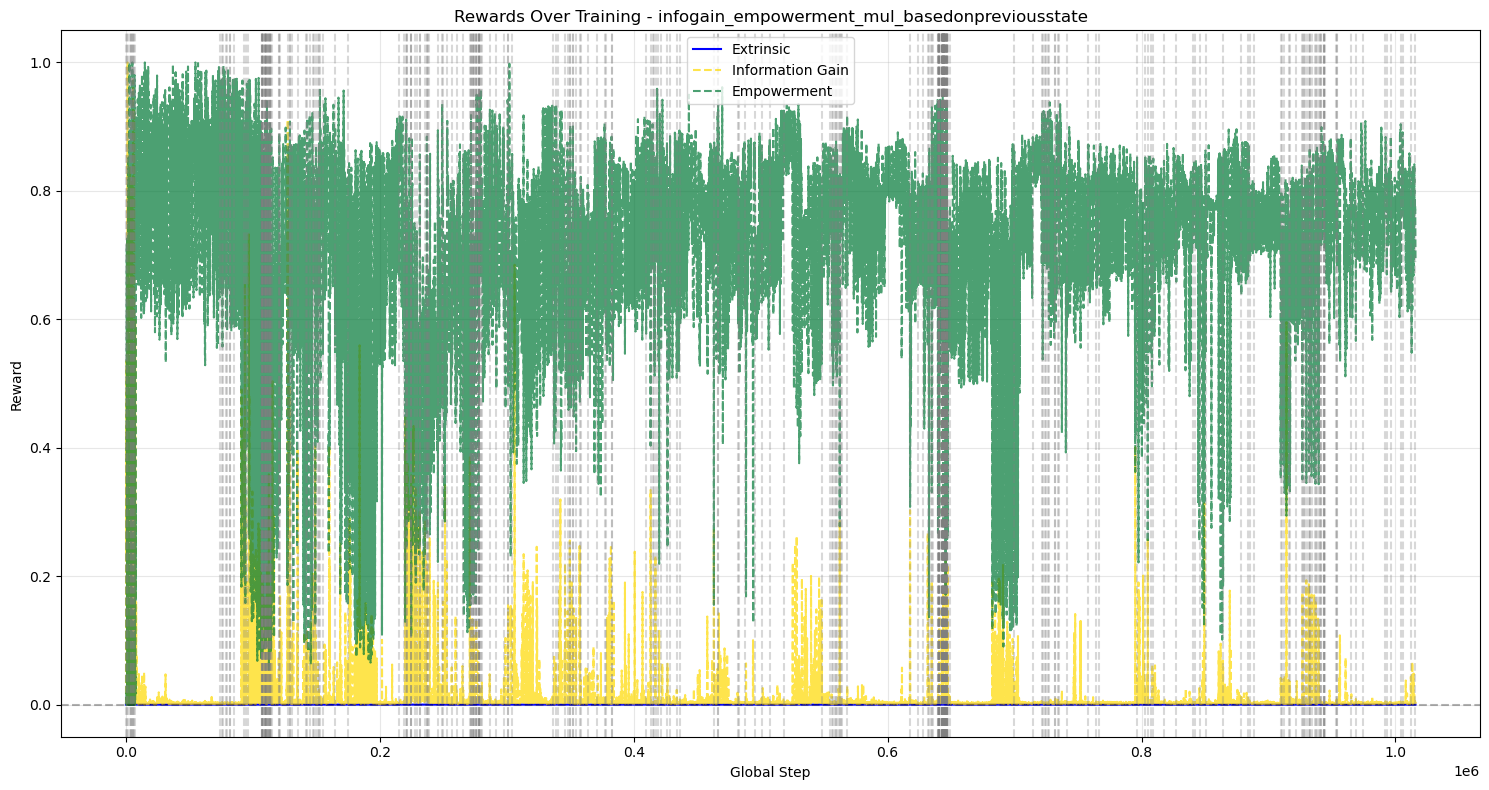


File boundaries (global step indices):
File 0: 0 to 1023
File 1: 1024 to 2047
File 2: 2048 to 3071
File 3: 3072 to 4095
File 4: 4096 to 5119
File 5: 5120 to 6143
File 6: 6144 to 7167
File 7: 7168 to 8191
File 8: 8192 to 9215
File 9: 9216 to 10239
File 10: 10240 to 11263
File 11: 11264 to 12287
File 12: 12288 to 13311
File 13: 13312 to 14335
File 14: 14336 to 15359
File 15: 15360 to 16383
File 16: 16384 to 17407
File 17: 17408 to 18431
File 18: 18432 to 19455
File 19: 19456 to 20479
File 20: 20480 to 21503
File 21: 21504 to 22527
File 22: 22528 to 23551
File 23: 23552 to 24575
File 24: 24576 to 25599
File 25: 25600 to 26623
File 26: 26624 to 27647
File 27: 27648 to 28671
File 28: 28672 to 29695
File 29: 29696 to 30719
File 30: 30720 to 31743
File 31: 31744 to 32767
File 32: 32768 to 33791
File 33: 33792 to 34815
File 34: 34816 to 35839
File 35: 35840 to 36863
File 36: 36864 to 37887
File 37: 37888 to 38911
File 38: 38912 to 39935
File 39: 39936 to 40959
File 40: 40960 to 41983
File 41:

In [13]:
replay_files, global_to_local_map, file_boundaries, episode_boundaries = analyze_training_data(step_interval=100)

We can see that the plot has a weird shape because the agent was trained on different environments in parallel, and the plot shows all of them. I've manually added another entry to the obs dict during training for now to distinguish them from one another (this is a bit dirty because this is technically the replay buffer and not logging, but we'll go with it for now)

In [8]:
replay_data_test = load_replay_data(replay_files[0])
ids = replay_data_test["env_id"]
ids # in one file, only one env_id is present

array([4, 4, 4, ..., 4, 4, 4])

In [9]:
[key for key in replay_data_test.keys()]

['image',
 'direction',
 'agent_pos_and_dir',
 'reward',
 'intrinsic_reward',
 'is_first',
 'is_last',
 'is_terminal',
 'extrinsic_reward',
 'intrinsic_reward_latent_infogain',
 'intrinsic_reward_latent_infogain_raw',
 'previous_posterior_deter',
 'current_posterior_deter',
 'current_prior_deter',
 'previous_posterior_logit',
 'current_posterior_logit',
 'current_prior_logit',
 'previous_posterior_stoch',
 'current_posterior_stoch',
 'current_prior_stoch',
 'intrinsic_reward_latent_empowerment',
 'intrinsic_reward_latent_empowerment_raw',
 'action',
 'reset',
 'env_id',
 'id']

In [30]:
replay_data_test = load_replay_data(replay_files[1])
ids = replay_data_test["env_id"]
ids # another file, another env_id 

array([2, 2, 2, ..., 2, 2, 2])

Either way, we can look at the agent's behavior at different times during training in more detail by selecting steps in 1024-size batches, since we always just data from one env in this way (probably not the same env but does not seem to matter for this analysis): 

In [ ]:
visualization_for_step_range(replay_files, global_to_local_map, 
                           start_step=10*1024, end_step=13*1024 + 1023, 
                           use_animation=False)

Extracting steps 10240 to 14335
Start: File 10, Local step 0
End: File 13, Local step 1023
Selected range spans 4 files
Visualizing 4096 steps
Highest intrinsic reward indices: [2476 3485 3847 2530 2484 3497 2522 3534 3483    7 2055   12 3489 3482
 3493 2518 3523 3521 2534 2533 3495 3180 3539 3505 2491   32 2542 2507
    4 3501]
Highest intrinsic reward values: [0.12508649 0.10876796 0.08885577 0.07610094 0.07015295 0.06860616
 0.06842276 0.06838437 0.0681179  0.06791219 0.067283   0.0648779
 0.06423143 0.06391937 0.06291216 0.06074145 0.06055755 0.06031594
 0.06023263 0.05902092 0.05896965 0.05885849 0.05881254 0.05777413
 0.05760486 0.05593485 0.05524689 0.05483984 0.05477325 0.05455639]
Lowest intrinsic reward indices: [3441 3345 2675 3348 1908 2857 3874 3397 2358 1832 1517 3398 3418 2715
 3870 4095 2590 3350 1721 4079 3337 2300 1611 1976 2784 3362 2780 1960
 2663 3436]
Lowest intrinsic reward values: [0.0000000e+00 2.8257520e-05 1.0165532e-04 1.0782311e-04 1.8060715e-04
 1.8180671e

Output()

None

In [19]:
# 195 because first 195 steps rewards are zero
visualization_for_step_range(replay_files, global_to_local_map, 
                           start_step=100*1024, end_step=100*1024 + 3000, 
                           use_animation=False)

Extracting steps 102400 to 105400
Start: File 100, Local step 0
End: File 102, Local step 952
Selected range spans 3 files
Visualizing 3001 steps
Highest intrinsic reward indices: [2055 1093 2059 2057 1027   57  715 2268  653   42 1113   73  267 1115
 1089 2135  619 2693  711 1085  117 2054 1083 2378  648 2154 2158 1199
 2374 2771]
Highest intrinsic reward values: [0.19530877 0.1370429  0.13207614 0.12059225 0.10730401 0.10726162
 0.09845072 0.09620562 0.09473428 0.09346428 0.09344119 0.09336946
 0.09311954 0.09298471 0.09285466 0.09214671 0.0919129  0.09116142
 0.09022579 0.08915187 0.0883363  0.08628034 0.08359431 0.08337557
 0.08312213 0.0826347  0.08241783 0.08236074 0.08159045 0.0811384 ]
Lowest intrinsic reward indices: [2346  279 1594  230 1611  859 2615 2611 2623  559 2619  563 1590 1231
 1598 1237 2631  579 1602 1582 2627 1606  575 2603 2327  242  571 1610
  380 1578]
Lowest intrinsic reward values: [0.00058683 0.00062641 0.00062803 0.00066049 0.000663   0.00067887
 0.00070414

Output()

None

In [10]:
# 195 because first 195 steps rewards are zero
visualization_for_step_range(replay_files, global_to_local_map, 
                           start_step=8*1024, end_step=8*1024 + 200000, 
                           use_animation=False)

Extracting steps 8192 to 208192
Start: File 8, Local step 0
End: File 203, Local step 320
Selected range spans 196 files
Visualizing 200001 steps
Highest intrinsic reward indices: [19331 16294 63094 66277 15313 27786 66276 27027 29051 45872 78166 41970
 66274 46175 41963 41966 27029 18592 21665 12150 16170 41964 90368 55924
 31419 23969 16626  2971 52089 45871]
Highest intrinsic reward values: [0.84114194 0.8123826  0.75364643 0.74982566 0.74804205 0.73699945
 0.69105846 0.6639528  0.65889055 0.65565133 0.65564513 0.6414907
 0.62312084 0.6227272  0.62195754 0.60395855 0.5980223  0.58781415
 0.58207345 0.57536674 0.5716208  0.5708213  0.55950165 0.5527886
 0.5519439  0.54912245 0.5429029  0.5410917  0.54063046 0.5376871 ]
Lowest intrinsic reward indices: [14672 14637  8524 14627 14623 14707 14652  8502 14660  8527  8476  8519
 14673  8702  8520  8494 14674  8483  8545 14667  8529  8515  8495  8511
 14675  8510 14657  8528 14669 14625]
Lowest intrinsic reward values: [0.01024328 0.010481

Output()

None

In [20]:
# 195 because first 195 steps rewards are zero
visualization_for_step_range(replay_files, global_to_local_map, 
                           start_step=880*1024, end_step=880*1024 + 50000, 
                           use_animation=False)

Extracting steps 901120 to 951120
Start: File 880, Local step 0
End: File 928, Local step 848
Selected range spans 49 files
Visualizing 50001 steps
Highest intrinsic reward indices: [20992 20983  1368  1375  3749 16282  5337 16322 16287 16154 16301 16218
  3136 16152 16279 16198  5185  1380  1398 16304  1502  1378  5187 16150
  3676  3760  3815 16295 16220  1374]
Highest intrinsic reward values: [0.7512463  0.7427717  0.74027914 0.73878366 0.73878366 0.73878366
 0.73778665 0.73579264 0.73579264 0.73479563 0.73479563 0.73479563
 0.7342971  0.7337986  0.7337986  0.7337986  0.7337986  0.7333001
 0.7333001  0.7328016  0.7328016  0.7328016  0.7328016  0.7328016
 0.7323031  0.7323031  0.7323031  0.7323031  0.7323031  0.7323031 ]
Lowest intrinsic reward indices: [18419 18417   568 18418  2690  2691 22239  4254   569 18416  2689 20994
   570 28698   567 31745 10421 10928 21500   572 21498   576 28699   573
   571   577   574 21497 10579 21503]
Lowest intrinsic reward values: [0.13334996 0.1333

Output()

None

**Observations**: Early in training:
* Info gain: Potentially useful signal, but unclear 
* Empowerment: initially zero (low-empowerment prior in tabular setting thus not so unrealistic?), needs some time to be estimated


In [ ]:
visualization_for_step_range(replay_files, global_to_local_map, 
                           start_step=8*1024, end_step=8*1024 + 100000, 
                           use_animation=False)

Extracting steps 8192 to 106495
Start: File 8, Local step 0
End: File 103, Local step 1023
Selected range spans 96 files
Visualizing 98304 steps
Highest intrinsic reward indices: [84806 79391 15866  8732 13851 78562 13810 93896  9649 14082]
Highest intrinsic reward values: [0.1013549  0.10058291 0.09535588 0.09217823 0.09187017 0.09156626
 0.09143566 0.09142242 0.09139206 0.09076803]
Lowest intrinsic reward indices: [58570 79798 23376 74674 81836 74672 85939 91226 67268 85716]
Lowest intrinsic reward values: [0.00016927 0.000178   0.00017947 0.00018154 0.00018265 0.00018371
 0.00018533 0.00018648 0.00018764 0.00018885]


Output()

None

In [ ]:
visualization_for_step_range(replay_files, global_to_local_map, 
                           start_step=104*1024, end_step=104*1024 + 1023, 
                           use_animation=False)

Extracting steps 106496 to 107519
Start: File 104, Local step 0
End: File 104, Local step 1023
Visualizing 1024 steps


interactive(children=(IntSlider(value=0, continuous_update=False, description='Step:', max=1023), Output()), _…

<function __main__.visualize_step_range.<locals>.plot_frame(frame)>

**Observations**: Later in training:
* Info gain: goes to zero, apart from ice states 
    
    → incorrect, measures aleatoric uncertainty, “noisy TV” problem
* Empowerment: ice states have lower empowerment than floor states
    
    → correct, aligns with intuition

In [13]:
visualization_for_step_range(replay_files, global_to_local_map, 
                           start_step=900*1024, end_step=990*1024+1023, 
                           use_animation=False)

Extracting steps 921600 to 1014783
Start: File 900, Local step 0
End: File 990, Local step 1023
Selected range spans 91 files
Visualizing 93184 steps


interactive(children=(IntSlider(value=0, continuous_update=False, description='Step:', max=93183), Output()), …

<function __main__.visualize_step_range.<locals>.plot_frame(frame)>

In [ ]:
# Try another range
visualization_for_step_range(replay_files, global_to_local_map, 
                           start_step=921600, end_step=921600+1030, 
                           use_animation=False);

Extracting steps 921600 to 922630
Start: File 900, Local step 0
End: File 901, Local step 6
Selected range spans 2 files
Visualizing 1031 steps


interactive(children=(IntSlider(value=0, continuous_update=False, description='Step:', max=1030), Output()), _…

<function __main__.visualize_step_range.<locals>.plot_frame(frame)>

--- 
## 2. Analysis of multiple runs

We've also saved the agents position and direction so that we can compute the same stats as in the tabular setting (number of discovered states, and how often the agent died in the process):

In [33]:
replay_data_test["agent_pos_and_dir"]

array([[10,  4,  3],
       [10,  4,  3],
       [10,  4,  3],
       ...,
       [ 8,  1,  3],
       [ 8,  1,  3],
       [ 8,  1,  3]])

['image',
 'direction',
 'agent_pos_and_dir',
 'reward',
 'intrinsic_reward',
 'is_first',
 'is_last',
 'is_terminal',
 'extrinsic_reward',
 'intrinsic_reward_latent_latentsinfogain',
 'intrinsic_reward_latent_latentsinfogain_raw',
 'latent_deter',
 'prev_latent_deter',
 'latent_logit',
 'prev_latent_logit',
 'latent_stoch',
 'prev_latent_stoch',
 'action',
 'reset',
 'env_id',
 'id']

In [7]:

def load_dreamer_runs(reward_agent_map, base_path="/mnt/lustre/work/wu/wkn758/dreamer_pretrain/mixedenv/MixedEnv"):
    """
    Load multiple Dreamer runs as specified by reward type to agent name mapping.
    
    Args:
        reward_agent_map: Dictionary mapping reward types to lists of agent names
        base_path: Base path to the Dreamer data
    
    Returns:
        Dictionary mapping reward types to lists of run data
    """
    results = {}

    DREAMER_REWARD_TYPE_TO_TABULAR_PARAMS = {
        "novelty": {
            'rewards': ["novelty"], 
            },
        "info_gain": {
            'rewards': ["info_gain"], 
            },
        "empowerment": {
            'rewards': ["empowerment"], 
            },
        "mean": {
            'rewards': ["info_gain", "empowerment"], 
            'combination_method': "mean"
            },
        "product": {
            'rewards': ["info_gain", "empowerment"], 
            'combination_method': "product"
            },
        "none":
            {
            'rewards': [], 
            },
    }
    
    for reward_type, agent_names in reward_agent_map.items():
        print(f"Loading data for reward: {reward_type}")
        param_key = reward_type
        results[param_key] = []
        
        for agent_name in agent_names:
            print(f"  Processing agent: {agent_name}")
            replay_path = os.path.join(base_path, agent_name, "replay")
            replay_files = sorted(glob.glob(os.path.join(replay_path, "*.npz")), 
                                key=os.path.getmtime)
            
            if not replay_files:
                print(f"  Warning: No replay files found for {agent_name}")
                continue
                
            # Process all replay files for this agent to extract transitions
            transitions = []
            visited_states = set()
            deaths = []
            
            for file_path in replay_files:
                try:
                    data = np.load(file_path, allow_pickle=True)
                                        
                    # Extract states from agent positions
                    states = data["agent_pos_and_dir"]
                    
                    # Extract termination information
                    # TODO: Does not work correctly because it includes truncation
                    # is_terminal = data["is_terminal"].astype(bool)
                    # For now, we will check if the agent is in a death cell
                    
                    # Create transitions similar to tabular format
                    for i in range(len(states)):
                        # Convert state to tuple for hashability
                        state = tuple(states[i])
                        
                        # Track visited states
                        visited_states.add(state)
                        
                        # Track deaths
                        is_terminal = (state[:2] in DEATH_CELLS)
                        deaths.append(is_terminal)
                        
                        # Store simplified transition similar to tabular format
                        # [state, action, reward, next_state, done]
                        # For our analysis we mainly need state and done
                        transitions.append([state, None, None, None, is_terminal])
                        
                except Exception as e:
                    print(f"  Error processing {file_path}: {e}")
            
            # Add this agent's data to results
            if transitions:
                params = DREAMER_REWARD_TYPE_TO_TABULAR_PARAMS[reward_type]
                results[param_key].append({
                    'params': params,
                    'history': {'transitions': transitions}
                })
                print(f"  Added {len(transitions)} transitions, {len(visited_states)} unique states, {sum(deaths)} deaths")
            else:
                print(f"  Warning: No valid transitions extracted for {agent_name}")
    
    return results

In [11]:
### Copied from exp003, TODO: put both in utils

def aggregate_cumulative_states_and_deaths(results, valid_states=None):
    """Aggregate statistics across multiple seeds."""
    all_states = []
    all_deaths = []
    all_states_to_death_ratios = []
    
    for result in results:
        # States
        transitions = result['history']['transitions']
        # count unique discovered states at each step
        states_over_time = []
        unique_states = set()
        
        for t in transitions:
            state = t[0]
            if valid_states is None or state in valid_states:
                unique_states.add(state)
                # Update state counts
            
            states_over_time.append(len(unique_states))
            
            #
            
        all_states.append(states_over_time)
        
        # Deaths
        deaths = np.cumsum([1 if t[4] else 0 for t in transitions])
        all_deaths.append(deaths)

        # States-to-deaths ratio
        states_to_death_ratios = np.array(states_over_time) / (np.array(deaths) + 1)
        all_states_to_death_ratios.append(states_to_death_ratios)
    
    states_array = np.array(all_states)
    deaths_array = np.array(all_deaths)
    states_to_death_ratios_array = np.array(all_states_to_death_ratios)
    
    return {
        'states_mean': np.mean(states_array, axis=0),
        'states_std': np.std(states_array, axis=0),
        'deaths_mean': np.mean(deaths_array, axis=0),
        'deaths_std': np.std(deaths_array, axis=0),
        'states_to_death_ratios_mean': np.mean(states_to_death_ratios_array, axis=0),
        'states_to_death_ratios_std': np.std(states_to_death_ratios_array, axis=0),
    }

def analyze_results(results, valid_states=None):
    """Analyze results and return processed statistics."""
    reward_results = {}
    ordered_rewards = ['novelty', 'info_gain', 'empowerment', 'mean', 'product', 'none']
    
    # First pass: organize results by reward type
    for param_key, seed_results in results.items():
        if not seed_results:
            continue
        
        stats = aggregate_cumulative_states_and_deaths(seed_results, valid_states=valid_states)
        params = seed_results[0]['params']
        
        # Determine reward type
        rewards = params["rewards"]
        if len(rewards) == 0:
            reward_str = "none"
        elif len(rewards) == 1:
            reward_str = rewards[0]
        elif len(rewards) > 1:
            if params["combination_method"] == "product":
                reward_str = "product"
            elif params["combination_method"] == "mean":
                reward_str = "mean"
                
        reward_results[reward_str] = (stats, params)
    
    return {
        'reward_results': reward_results,
        'ordered_rewards': ordered_rewards
    }

def plot_learning_curves_with_variance(analyzed_data, save_path="figures"):
    """Plot learning curves with mean and standard deviation across seeds."""
    import os
    
    reward_results = analyzed_data['reward_results']
    ordered_rewards = analyzed_data['ordered_rewards']
    
    # Create directory if it doesn't exist
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    # Set figure style for publication using just matplotlib
    plt.rcParams.update(plt.rcParamsDefault)
    plt.rcParams.update({
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
    })
    
    # Create combined figure
    fig_combined, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 4))
    
    # Create individual figures
    fig_states = plt.figure(figsize=(6, 4))
    ax_states = fig_states.add_subplot(111)
    
    fig_deaths = plt.figure(figsize=(6, 4))
    ax_deaths = fig_deaths.add_subplot(111)
    
    fig_ratio = plt.figure(figsize=(6, 4))
    ax_ratio = fig_ratio.add_subplot(111)
    
    
    # Colors matching the image
    color_map = {
        'none': '#000000',             # black
        'novelty': '#0063be',          # blue
        'info_gain': '#fed900',        # yellow/gold
        'empowerment': '#007836',      # green
        'mean': '#ff6f20',             # orange
        'product': '#580f8b'           # purple
    }
    
    # Plot in specific order
    labels = []
    final_ratios = []
    final_stds = []
    
    for reward_str in ordered_rewards:
        if reward_str not in reward_results:
            continue
            
        stats, params = reward_results[reward_str]
        color = color_map[reward_str]
        x = np.arange(len(stats['states_mean']))
        
        # Plot on combined figure
        for ax, ax_single, data_mean, data_std, title, ylabel in [
            (ax1, ax_states, stats['states_mean'], stats['states_std'], 'State Discovery', '# Unique States'),
            (ax2, ax_deaths, stats['deaths_mean'], stats['deaths_std'], 'Cumulative Deaths', 'Deaths'),
        ]:
            # Plot on combined figure
            ax.plot(x, data_mean, label=reward_str, color=color, linewidth=2)
            ax.fill_between(x, data_mean - data_std, data_mean + data_std, alpha=0.15, color=color)
            
            # Plot on individual figure
            ax_single.plot(x, data_mean, label=reward_str, color=color, linewidth=2)
            ax_single.fill_between(x, data_mean - data_std, data_mean + data_std, alpha=0.15, color=color)
            
            # Style individual figure
            ax_single.spines['top'].set_visible(False)
            ax_single.spines['right'].set_visible(False)
            ax_single.tick_params(labelsize=10)
            ax_single.grid(True, linestyle='--', alpha=0.3)
            ax_single.set_xlabel('Steps', fontsize=11)
            ax_single.set_ylabel(ylabel, fontsize=11)
            ax_single.set_title(title, fontsize=12, pad=10)
        
        # Store data for bar plot
        labels.append(reward_str)
        final_ratios.append(stats['states_to_death_ratios_mean'][-1])
        final_stds.append(stats['states_to_death_ratios_std'][-1])
    
    # Bar plot with improved styling (combined and individual)
    x_pos = np.arange(len(labels))
    for ax_bar in [ax3, ax_ratio]:
        bars = ax_bar.bar(x_pos, final_ratios, yerr=final_stds, 
                         capsize=4, 
                         color=[color_map[label] for label in labels],
                         error_kw={'elinewidth': 1.5, 'capthick': 1.5})
        ax_bar.set_xlabel('Reward Type', fontsize=11)
        ax_bar.set_ylabel('Discovery-to-Deaths Ratio', fontsize=11)
        ax_bar.set_title('Final Discovery-to-Deaths Ratio', fontsize=12, pad=10)
        ax_bar.set_xticks(x_pos)
        ax_bar.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
        ax_bar.spines['top'].set_visible(False)
        ax_bar.spines['right'].set_visible(False)
        ax_bar.tick_params(labelsize=10)
        ax_bar.grid(True, linestyle='--', alpha=0.3)
    
    # Save individual figures
    fig_states.tight_layout()
    fig_states.savefig(os.path.join(save_path, 'state_discovery.png'), dpi=300, bbox_inches='tight')
    
    fig_deaths.tight_layout()
    fig_deaths.savefig(os.path.join(save_path, 'cumulative_deaths.png'), dpi=300, bbox_inches='tight')
    
    fig_ratio.tight_layout()
    fig_ratio.savefig(os.path.join(save_path, 'discovery_death_ratio.png'), dpi=300, bbox_inches='tight')
    
    # Save combined figure
    fig_combined.tight_layout()
    fig_combined.savefig(os.path.join(save_path, 'combined_plots.png'), dpi=300, bbox_inches='tight')
    
    # Close individual figures
    plt.close(fig_states)
    plt.close(fig_deaths)
    plt.close(fig_ratio)
    
    return fig_combined

In [14]:
# for multiple seeds, simply pass the list of directories for each reward
# dreamer_reward_map = {
#     'novelty': ['latentsnovelty'],
#     'info_gain': ['latentsinfogain'],
#     'empowerment': ['latentsempowerment'],
#     'mean': ['infogain_empowerment_mean'],
#     'product': ['infogain_empowerment_mul'],
#     'none': ['none'],
# }

# dreamer_reward_map = {
#     'novelty': ['latentsnovelty'],
#     'info_gain': ['latentsinfogain'],
#     'empowerment': ['latentsempowerment'],
#     'mean': ['infogain_empowerment_mean'],
#     'product': ['infogain_empowerment_mul'],
# }

dreamer_reward_map = {
    'novelty': ['latentsnovelty'],
    'info_gain': ['latentsinfogain'],
    'mean': ['infogain_empowerment_mean_basedonpreviousstate'],
    'product': ['infogain_empowerment_mul_basedonpreviousstate'],
    'empowerment': ['latentsempowerment'],
}


# dreamer_reward_map = {
#     'empowerment': ['latentsempowerment'],
#     'info_gain': ['wallsblockview_latentsinfogain_withminmax'],
# }

In [15]:
results = load_dreamer_runs(dreamer_reward_map, base_path=BASE_PATH)

Loading data for reward: novelty
  Processing agent: latentsnovelty
  Added 1015808 transitions, 259 unique states, 82 deaths
Loading data for reward: info_gain
  Processing agent: latentsinfogain
  Added 1015808 transitions, 343 unique states, 217 deaths
Loading data for reward: mean
  Processing agent: infogain_empowerment_mean_basedonpreviousstate
  Added 1015808 transitions, 54 unique states, 15 deaths
Loading data for reward: product
  Processing agent: infogain_empowerment_mul_basedonpreviousstate
  Added 1015808 transitions, 347 unique states, 253 deaths
Loading data for reward: empowerment
  Processing agent: latentsempowerment
  Added 1015808 transitions, 55 unique states, 7 deaths


In [16]:
analyzed_data = analyze_results(results)

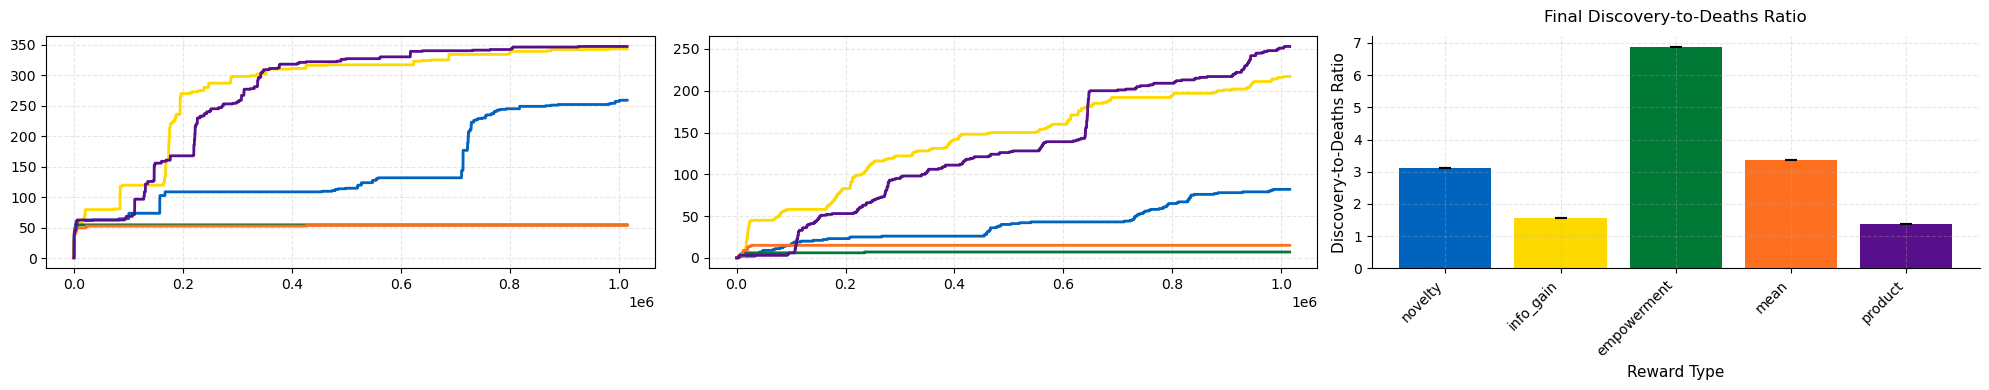

In [17]:
plot_learning_curves_with_variance(analyzed_data, save_path="../fig/dreamer/")

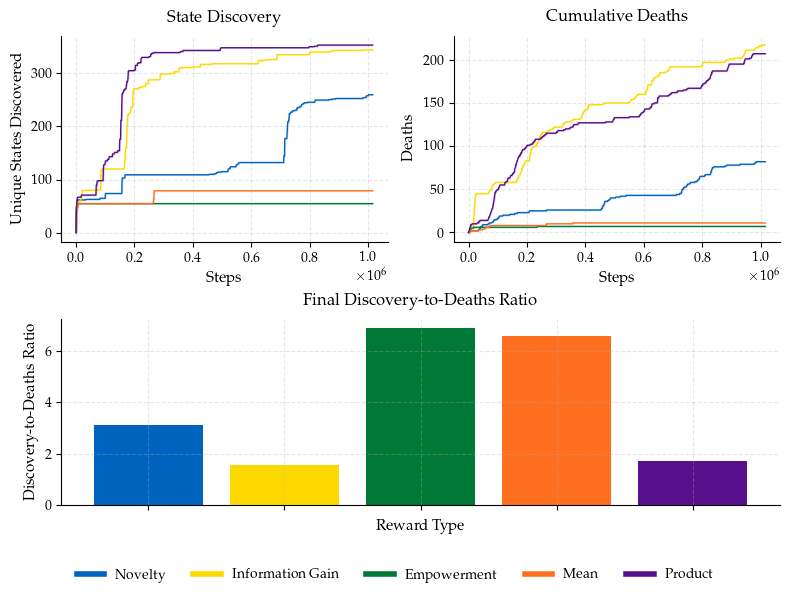

In [36]:
plot_learning_curves_with_variance2(analyzed_data, save_path="../fig/dreamer/", subsample=True)

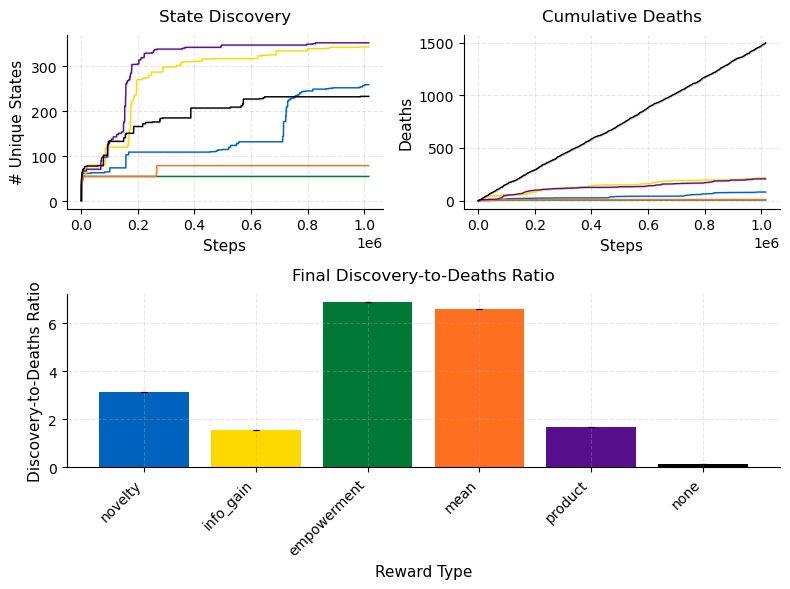

In [17]:
plot_learning_curves_with_variance2(analyzed_data, save_path="../fig/dreamer_with_random/")

In [35]:
import os
import matplotlib.pyplot as plt
import numpy as np

LABELS_TO_NICE_NAMES = {
    'none': 'Random',
    'novelty': 'Novelty',
    'info_gain': 'Information Gain',
    'empowerment': 'Empowerment',
    'mean': 'Mean',
    'product': 'Product'
}

def plot_learning_curves_with_variance2(analyzed_data, save_path="figures", subsample=False):
    """Plot learning curves with mean and standard deviation across seeds, optimized for single-column paper format."""
    
    reward_results = analyzed_data['reward_results']
    ordered_rewards = analyzed_data['ordered_rewards']
    
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    # Set figure style for publication using matplotlib
    plt.rcParams.update(plt.rcParamsDefault)
    plt.rcParams.update({
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
        "text.usetex": True,
        "font.family": "Palatino"
    })
    
    fig_combined = plt.figure(figsize=(8, 6))  # Slightly taller to accommodate legend
    
    # Create a custom gridspec with room for legend at bottom
    gs = fig_combined.add_gridspec(2, 2, height_ratios=[1, 0.9])
    
    # Create axes - top row has two plots, bottom row has one centered plot
    ax1 = fig_combined.add_subplot(gs[0, 0])
    ax2 = fig_combined.add_subplot(gs[0, 1])
    ax3 = fig_combined.add_subplot(gs[1, :])  # Spans both columns
    
    color_map = {
        'none': '#000000',
        'novelty': '#0063be',
        'info_gain': '#fed900',
        'empowerment': '#007836',
        'mean': '#ff6f20',
        'product': '#580f8b'
    }
    
    # Plot in specific order
    labels = []
    final_ratios = []
    final_stds = []
    legend_handles = []
    
    for reward_str in ordered_rewards:
        if reward_str not in reward_results:
            continue
            
        stats, params = reward_results[reward_str]
        color = color_map[reward_str]
        x = np.arange(len(stats['states_mean']))

        if subsample:
            indices = np.linspace(0, len(stats['states_mean'])-1, 1000, dtype=int)
            
            # Downsample all data arrays
            states_mean = stats['states_mean'][indices]
            states_std = stats['states_std'][indices]
            deaths_mean = stats['deaths_mean'][indices]
            deaths_std = stats['deaths_std'][indices]
            x = x[indices]
        else:
            states_mean = stats['states_mean']
            states_std = stats['states_std']
            deaths_mean = stats['deaths_mean']
            deaths_std = stats['deaths_std']
        
        # Plot first two subplots
        for ax, data_mean, data_std, title, ylabel in [
            (ax1, states_mean, states_std, 'State Discovery', 'Unique States Discovered'),
            (ax2, deaths_mean, deaths_std, 'Cumulative Deaths', 'Deaths'),
        ]:
            line, = ax.plot(x, data_mean, color=color, linewidth=1)
            ax.fill_between(x, data_mean - data_std, data_mean + data_std, alpha=0.15, color=color)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.tick_params(labelsize=10)
            ax.grid(True, linestyle='--', alpha=0.3)
            ax.set_xlabel('Steps', fontsize=11)
            ax.set_ylabel(ylabel, fontsize=11)
            ax.set_title(title, fontsize=12, pad=10)
            
            if ax == ax1:  # Only store handles from the first plot for the legend
                legend_handles.append(line)
        
        # Store data for bar plot
        labels.append(reward_str)
        final_ratios.append(stats['states_to_death_ratios_mean'][-1])
        final_stds.append(stats['states_to_death_ratios_std'][-1])
    
    # Bar plot
    x_pos = np.arange(len(labels))
    bars = ax3.bar(x_pos, final_ratios, #yerr=final_stds, 
                   # capsize=2, 
                   color=[color_map[label] for label in labels],
                   #error_kw={'elinewidth': 0.8, 'capthick': 0.8}
                   )
    ax3.set_xticks(x_pos)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    ax3.set_xlabel('Reward Type', fontsize=11)
    ax3.set_ylabel('Discovery-to-Deaths Ratio', fontsize=11)
    ax3.set_title('Final Discovery-to-Deaths Ratio', fontsize=12, pad=10)
    
    # Remove x-ticks for cleaner look
    ax3.set_xticklabels([])
    
    # Add horizontal legend at the bottom of the figure
    legend = fig_combined.legend(
        handles=legend_handles,
        labels=[LABELS_TO_NICE_NAMES[label] for label in labels],
        loc='lower center', 
        bbox_to_anchor=(0.5, 0.00),
        ncol=len(labels),  # Horizontal layout
        frameon=False,
        fontsize=10,
    )

    # make lines in legend thicker
    for line in legend.get_lines():
        line.set_linewidth(4.0)
    
    # Adjust layout
    plt.tight_layout()
    
    # Adjust layout to make room for the legend
    plt.subplots_adjust(bottom=0.15)
    
    # Save combined figure
    fig_combined.savefig(os.path.join(save_path, 'combined_plots.pdf'), 
                        dpi=300, 
                        bbox_inches='tight',
                        pad_inches=0.1)
    
    return fig_combined